---
title: "Minimizing the average travel time to sites"
image: image.png
toc: true
execute: 
  enabled: true
---

First, we need to import and initialise the SiteProblem class. 

In [1]:
from lokigi.site import SiteProblem
import pandas as pd

In [2]:
problem = SiteProblem()

Let's see what models are currently supported. 

In [3]:
problem.describe_models(available_only=True)

=== Supported Healthcare Location Models ===

ID: p_median
Name: P-Median (Average Distance Minimizer)
Goal: Minimize the total travel distance for the entire population.
When to use: Best for general primary care where you want the 'average' patient to have the shortest trip possible.
Main Trade-off: Can leave remote or rural patients with very long travel times in favor of urban density.

To run a model, use: prob.solve_pmedian(p=3) or similar.


And what models will be supported in the future?

In [4]:
problem.describe_models(available_only=False)

=== Healthcare Location Models ===

ID: p_median
Name: P-Median (Average Distance Minimizer)
Goal: Minimize the total travel distance for the entire population.
When to use: Best for general primary care where you want the 'average' patient to have the shortest trip possible.
Main Trade-off: Can leave remote or rural patients with very long travel times in favor of urban density.
Status: Supported

ID: mclp
Name: Maximal Coverage Location Problem (MCLP)
Goal: Maximize the number of people within a specific time/distance 'threshold' (e.g., 15 minutes).
When to use: Best for emergency services (Ambulance/ER) where getting there within a 'Golden Hour' is more important than the average trip time.
Main Trade-off: Does not care how far away people are once they are outside the threshold.
Status: Planned

ID: lscp
Name: Location Set Covering Location Problem (LSCP)
Goal: Find the minimum number of facilities needed to cover *everyone* within a certain distance.
When to use: Best for universa

## Initialising required data

The `show_` methods help us to see what format lokigi expects our data to be in. 

In [5]:
problem.show_demand_format()


--- Expected Demand DataFrame Format ---
Note: Each row represents a unique demand location (e.g., LSOA).
site_id_col     | demand_col
------------------------------
LSOA 1          | 25        
LSOA 2          | 15        
...             | ...       
----------------------------------------



In [6]:
problem.show_travel_format()


--- Expected Travel/Cost DataFrame Format ---
Note: Rows are sources, columns are destinations.
source_id       | dest_1          | dest_2         
--------------------------------------------------
source_1        | 22.6            | 16.3           
source_2        | 15.1            | 17.1           
...             | ...             | ...            
--------------------------------------------

For example, if using LSOAs, your dataframe might look like this:
source_id       | E01000259       | E01000314      
--------------------------------------------------
Brighton and Hove 027E | 22.6            | 16.3           
Brighton and Hove 005C | 15.1            | 17.1           
...             | ...             | ...            
--------------------------------------------

Or if you've defined your site names, it might look like this:
source_id       | Site 1          | Site 1         
--------------------------------------------------
Brighton and Hove 027E | 22.6            | 16.3

## Add the required data

We can now use the various `add_` methods to add in the required datasets. 

### Historical Demand

In [7]:
problem.add_demand("../../../sample_data/brighton_demand.csv", demand_col="demand", location_id_col="LSOA")

In [8]:
problem.show_demand()

,LSOA,demand
0,Brighton and Hove 027E,3627
1,Brighton and Hove 027F,2323
2,Brighton and Hove 027A,2596
3,Brighton and Hove 029E,3132
4,Brighton and Hove 029D,2883
...,...,...
160,Brighton and Hove 012A,2497
161,Brighton and Hove 005C,2570
162,Brighton and Hove 012B,2051
163,Brighton and Hove 005A,1164


### Candidate Sites

In [9]:
problem.add_sites("../../../sample_data/brighton_sites.geojson", candidate_id_col="site")

In [10]:
problem.show_sites()

,site,geometry
0,Site 1,POINT (527142.275 106616.053)
1,Site 2,POINT (531493.995 106639.488)
2,Site 3,POINT (533356.778 105476.782)
3,Site 4,POINT (528513.424 105052.43)
4,Site 5,POINT (532421.163 109069.196)
5,Site 6,POINT (528716.452 108042.794)


We can also plot the sites we've just put in.

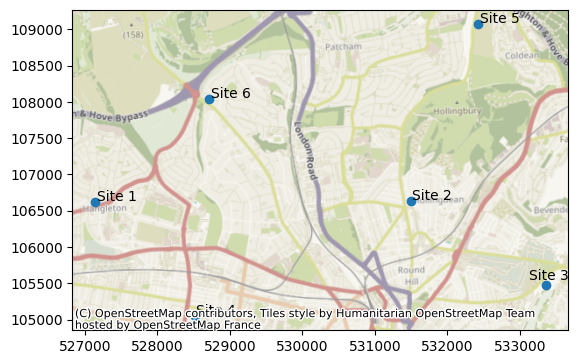

In [11]:
problem.plot_sites()

### Travel Data

Our travel matrix is in seconds. Let's update this to minutes when we load it in.

In [12]:
problem.add_travel_matrix(
    travel_matrix_df="../../../sample_data/brighton_travel_matrix_driving.csv",
    source_col="LSOA",
    from_unit="seconds",
    to_unit="minutes"
    )

In [13]:
problem.travel_matrix

,LSOA,Site 1,Site 2,Site 3,Site 4,Site 5,Site 6
0,Brighton and Hove 027E,12.898833,8.794833,7.404833,8.197500,10.125667,9.248500
1,Brighton and Hove 027F,12.623167,8.318500,8.626167,9.351167,9.649500,8.972833
2,Brighton and Hove 027A,12.720667,10.023000,8.633000,6.840000,11.353833,9.289167
3,Brighton and Hove 029E,12.393667,10.862000,11.006000,6.328667,12.193000,9.293000
4,Brighton and Hove 029D,11.097500,11.077500,10.970000,5.216667,12.408333,9.508500
...,...,...,...,...,...,...,...
160,Brighton and Hove 012A,7.442333,14.745000,18.468500,8.652667,10.433667,7.463000
161,Brighton and Hove 005C,7.830000,13.080500,16.804000,9.490000,8.769167,5.798500
162,Brighton and Hove 012B,7.742167,15.153000,18.876667,8.952500,10.841833,7.871000
163,Brighton and Hove 005A,9.458167,14.708667,18.432167,11.068500,10.397333,7.426667


### Region Geometry

We'll also want to add in a region geometry layer (a geodataframe containing the boundaries for the areas defined in our demand data) if we want to be able to plot some of our outputs.

In [14]:
problem.add_region_geometry_layer("https://github.com/hsma-programme/h6_3d_facility_location_problems/raw/refs/heads/main/h6_3d_facility_location_problems/example_code/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson", common_col="LSOA11NM")

In [15]:
# problem.add_region_geometry_layer("../../../sample_data/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson", common_col="LSOA11NM")

In [16]:
problem.region_geometry_layer

,FID,LSOA11CD,LSOA11NM,LSOA11NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,1,E01000001,City of London 001A,City of London 001A,532123,181632,-0.097140,51.51816,a758442e-7679-45d0-95a8-ed4c968ecdaa,"POLYGON ((532282.629 181906.496, 532248.25 181..."
1,2,E01000002,City of London 001B,City of London 001B,532480,181715,-0.091970,51.51882,861dbb53-dfaf-4f57-be96-4527e2ec511f,"POLYGON ((532746.814 181786.892, 532248.25 181..."
2,3,E01000003,City of London 001C,City of London 001C,532239,182033,-0.095320,51.52174,9f765b55-2061-484a-862b-fa0325991616,"POLYGON ((532293.068 182068.422, 532419.592 18..."
3,4,E01000005,City of London 001E,City of London 001E,533581,181283,-0.076270,51.51468,a55c4c31-ef1c-42fc-bfa9-07c8f2025928,"POLYGON ((533604.245 181418.129, 533743.689 18..."
4,5,E01000006,Barking and Dagenham 016A,Barking and Dagenham 016A,544994,184274,0.089317,51.53875,9cdabaa8-d9bd-4a94-bb3b-98a933ceedad,"POLYGON ((545271.918 184183.948, 545296.314 18..."
...,...,...,...,...,...,...,...,...,...,...
34748,34749,W01001954,Cardiff 006F,Caerdydd 006F,312959,180574,-3.255820,51.51735,5fc2d16e-8663-462f-936d-7535d0de1732,"POLYGON ((313011.929 181083.89, 313533.809 180..."
34749,34750,W01001955,Swansea 025F,Abertawe 025F,265633,193182,-3.942370,51.62137,0bcc9472-48d1-460c-a40e-c4a745269d84,"POLYGON ((266079.095 193572.406, 266140.774 19..."
34750,34751,W01001956,Swansea 023E,Abertawe 023E,260586,192621,-4.015000,51.61510,557e08ba-6aee-491d-8ba1-79eca916ce6b,"POLYGON ((260107.578 194891.58, 260436.897 194..."
34751,34752,W01001957,Swansea 025G,Abertawe 025G,265337,192555,-3.946400,51.61567,43f945c4-e97d-4b1f-9e4d-46d154a6662e,"POLYGON ((264991.859 192395.89, 264913.891 192..."


<Axes: >

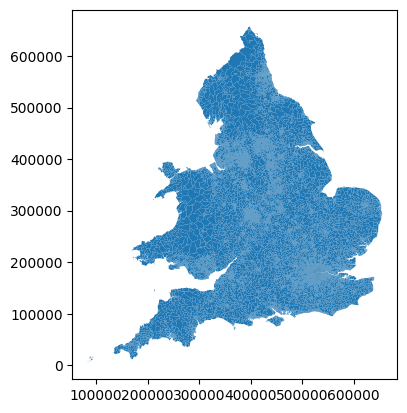

In [17]:
problem.region_geometry_layer.plot()

## Evaluating a single solution

Generally we're going to want to evaluate lots of solutions at once to find the optimum one. 

However, we can also choose to evaluate a single solution. 

In [18]:
combo_1 = problem.evaluate_single_solution(site_names=["Site 1", "Site 2"], objectives="p-median")
combo_1

In [ ]:
combo_1.return_solution_metrics()

{'site_names': ['Site 1', 'Site 2'],
 'site_indices': array([0, 1]),
 'weighted_average': np.float64(8.450685200470566),
 'unweighted_average': np.float64(8.152459595959595),
 '90th_percentile': np.float64(11.978799999999998),
 'max': np.float64(23.921),
 'problem_df':                        LSOA                  LSOA_x     Site 1     Site 2  \
 0    Brighton and Hove 027E  Brighton and Hove 027E  12.898833   8.794833   
 1    Brighton and Hove 027F  Brighton and Hove 027F  12.623167   8.318500   
 2    Brighton and Hove 027A  Brighton and Hove 027A  12.720667  10.023000   
 3    Brighton and Hove 029E  Brighton and Hove 029E  12.393667  10.862000   
 4    Brighton and Hove 029D  Brighton and Hove 029D  11.097500  11.077500   
 ..                      ...                     ...        ...        ...   
 160  Brighton and Hove 012A  Brighton and Hove 012A   7.442333  14.745000   
 161  Brighton and Hove 005C  Brighton and Hove 005C   7.830000  13.080500   
 162  Brighton and Hove 012B 

Instead of site names, we could pass site indices. Remember - Python is a 0 indexed language (i.e. starts counting from 0) so this might not behave exactly as you're expecting if you're not familiar with thinking in this way. 

In [20]:
combo_2 = problem.evaluate_single_solution(site_indices=[1,2], objectives="p median")
combo_2.evaluated_combination_df

,LSOA,LSOA_x,Site 2,Site 3,min_cost,LSOA_y,demand
0,Brighton and Hove 027E,Brighton and Hove 027E,8.794833,7.404833,7.404833,Brighton and Hove 027E,3627
1,Brighton and Hove 027F,Brighton and Hove 027F,8.318500,8.626167,8.318500,Brighton and Hove 027F,2323
2,Brighton and Hove 027A,Brighton and Hove 027A,10.023000,8.633000,8.633000,Brighton and Hove 027A,2596
3,Brighton and Hove 029E,Brighton and Hove 029E,10.862000,11.006000,10.862000,Brighton and Hove 029E,3132
4,Brighton and Hove 029D,Brighton and Hove 029D,11.077500,10.970000,10.970000,Brighton and Hove 029D,2883
...,...,...,...,...,...,...,...
160,Brighton and Hove 012A,Brighton and Hove 012A,14.745000,18.468500,14.745000,Brighton and Hove 012A,2497
161,Brighton and Hove 005C,Brighton and Hove 005C,13.080500,16.804000,13.080500,Brighton and Hove 005C,2570
162,Brighton and Hove 012B,Brighton and Hove 012B,15.153000,18.876667,15.153000,Brighton and Hove 012B,2051
163,Brighton and Hove 005A,Brighton and Hove 005A,14.708667,18.432167,14.708667,Brighton and Hove 005A,1164


## Evaluating multiple solutions

Let's now work out the best possible combination of 3 sites of the 6 candidate sites. 

In [21]:
solutions = problem.solve(p=3, objectives="p-median")
solutions

In [22]:
solutions.show_solutions()

,site_names,site_indices,weighted_average,unweighted_average,90th_percentile,max,problem_df
0,None,"[2, 3, 4]",5.37,5.45,8.50,16.69,LSOA L...
1,None,"[2, 3, 5]",5.38,5.36,8.06,16.69,LSOA L...
2,None,"[0, 2, 3]",5.53,5.67,9.36,16.69,LSOA L...
3,None,"[1, 2, 3]",5.54,5.59,9.00,16.69,LSOA L...
4,None,"[0, 2, 5]",6.32,6.21,9.33,16.69,LSOA L...
5,None,"[0, 2, 4]",6.35,6.32,9.70,16.69,LSOA L...
6,None,"[2, 4, 5]",6.42,6.29,9.26,16.69,LSOA L...
7,None,"[0, 1, 2]",6.47,6.39,9.77,16.69,LSOA L...
8,None,"[1, 2, 5]",6.51,6.31,9.45,16.69,LSOA L...
9,None,"[1, 3, 4]",6.92,6.76,11.32,21.71,LSOA L...


In [23]:
len(solutions.show_solutions())

20

### Travel Time Distributions for best outputs

In [24]:
solutions.plot_travel_time_distribution()

In [25]:
solutions.plot_travel_time_distribution(5)

In [26]:
solutions.plot_travel_time_distribution(5, compare_to_best=True)

In [27]:
solutions.plot_travel_time_distribution(5, compare_to_best=True, rank_on="max")

### Plotting solutions

<Axes: title={'center': 'Weighted average travel time for the best 3 site combination'}>

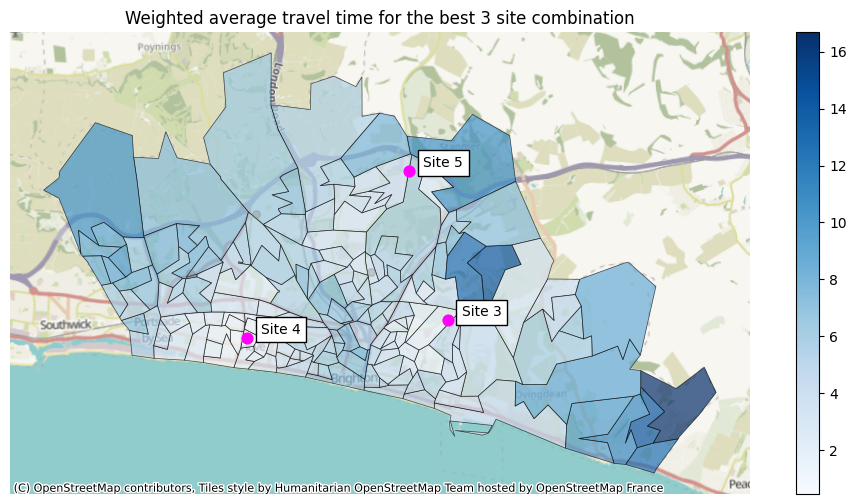

In [28]:
solutions.plot_best_combination(title="Weighted average travel time for the best 3 site combination")

We can also choose to plot multiple possible combinations. 

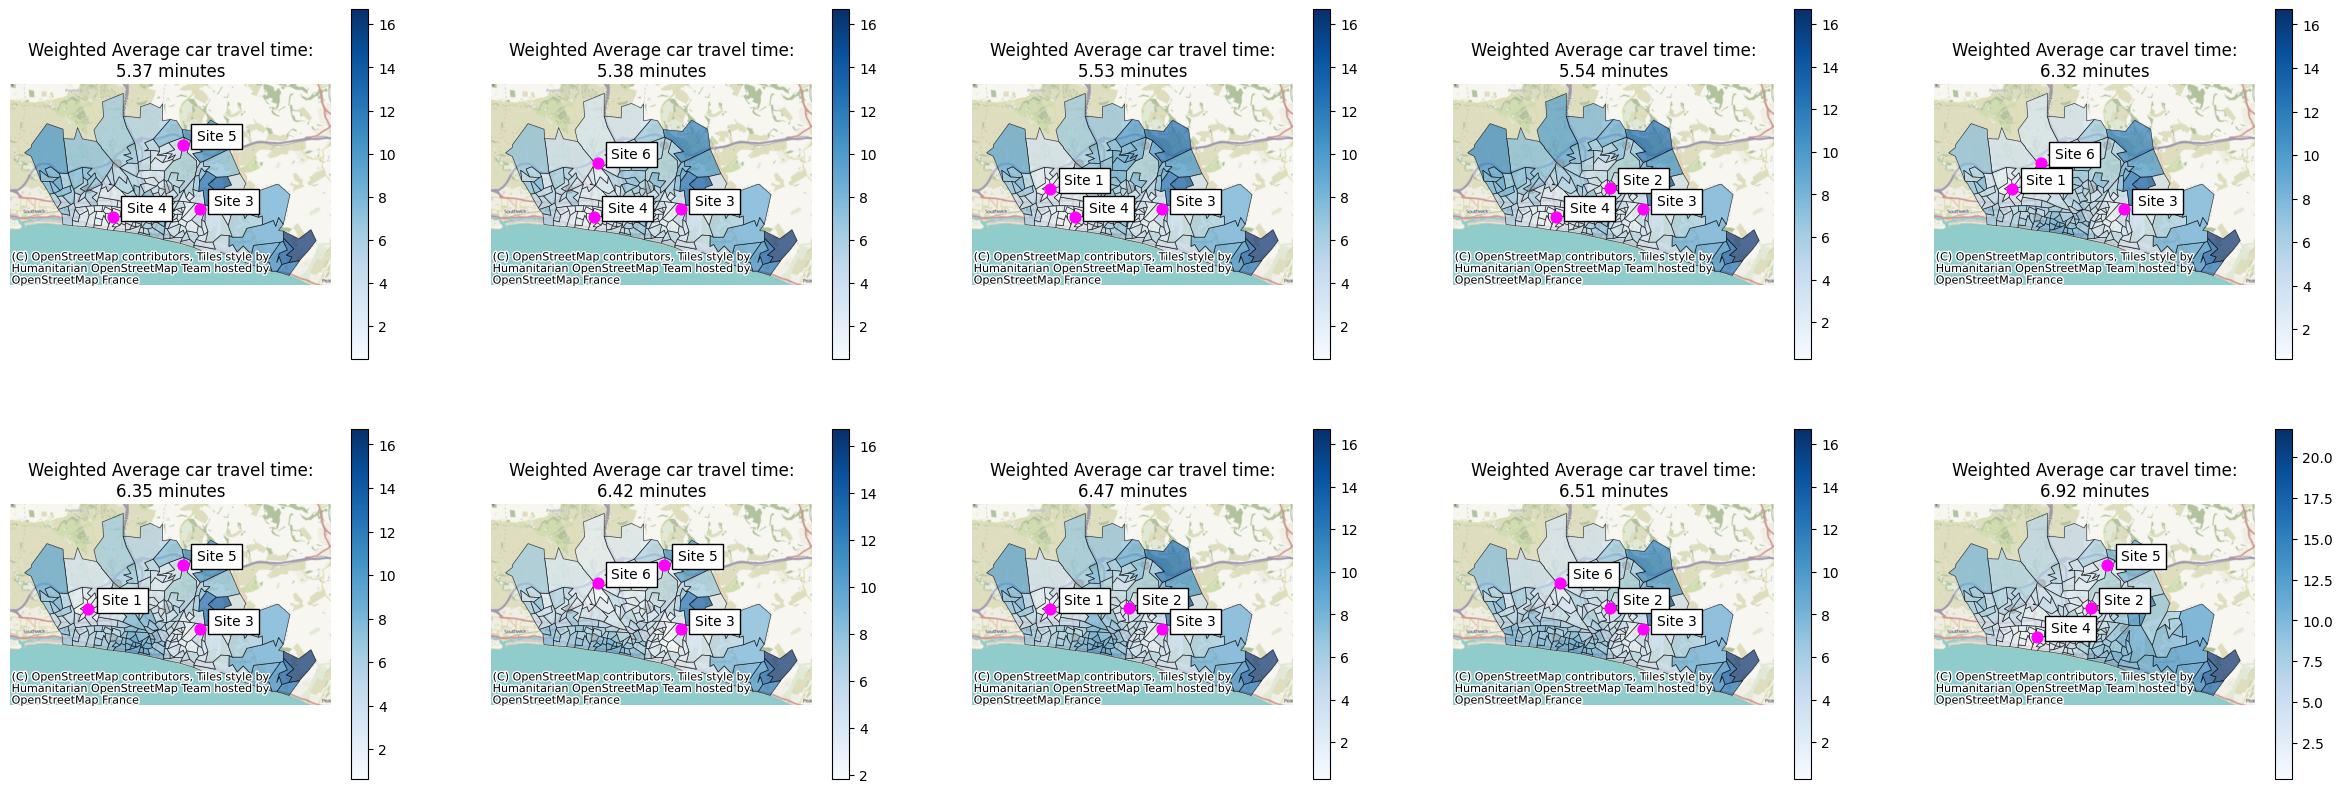

In [29]:
solutions.plot_n_best_combinations(subplot_title="Weighted Average car travel time:\n{solution['weighted_average'].values[0]:.2f} minutes")

We can change what the solutions are ranked on - here we rate by the maximum travel time seen by any one LSOA, and display that instead. 

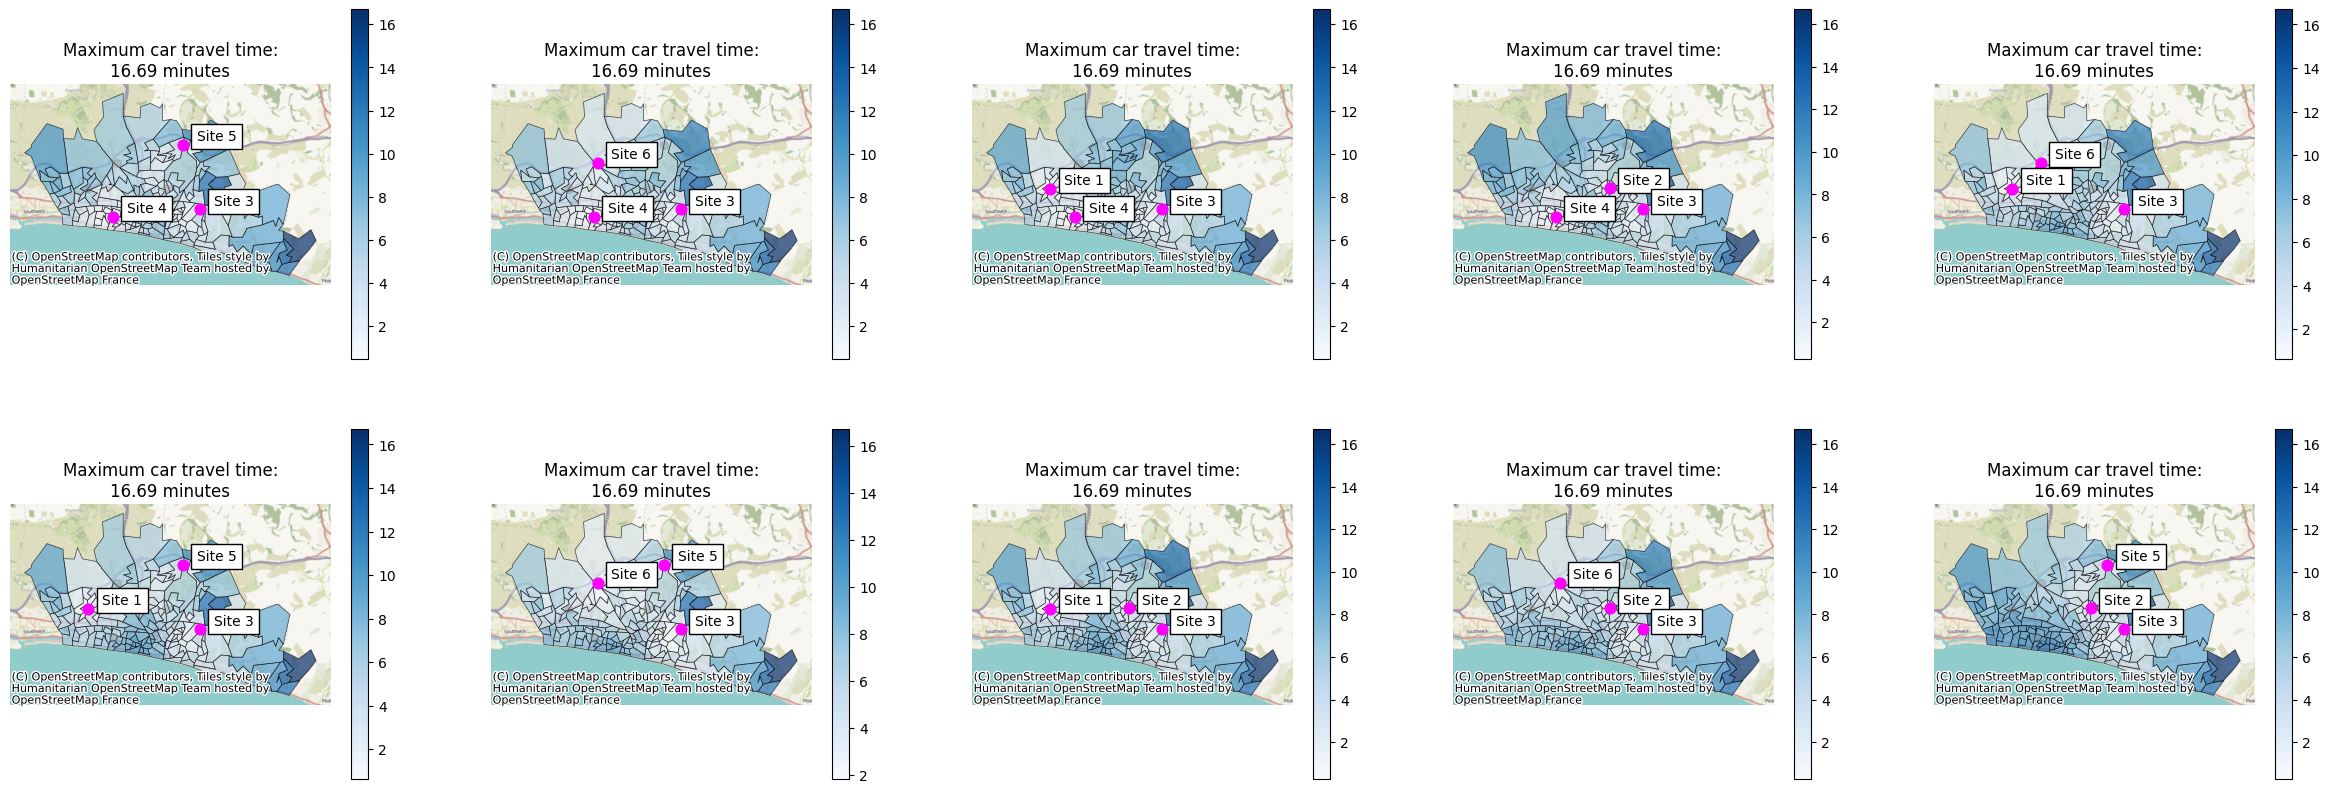

In [30]:
solutions.plot_n_best_combinations(rank_on="max", subplot_title="Maximum car travel time:\n{solution['max'].values[0]:.2f} minutes")

# Try all different possible combinations

Let's now explore the variation we see with a range of sites. 

In [31]:
solutions_5 = problem.solve(p=5, objectives="p-median")
solutions_5.show_solutions()

,site_names,site_indices,weighted_average,unweighted_average,90th_percentile,max,problem_df
0,None,"[0, 2, 3, 4, 5]",4.96,4.88,7.42,16.69,LSOA L...
1,None,"[0, 1, 2, 3, 4]",4.99,5.00,7.78,16.69,LSOA L...
2,None,"[1, 2, 3, 4, 5]",5.02,4.93,7.42,16.69,LSOA L...
3,None,"[0, 1, 2, 3, 5]",5.05,4.90,7.67,16.69,LSOA L...
4,None,"[0, 1, 2, 4, 5]",5.97,5.79,9.07,16.69,LSOA L...
5,None,"[0, 1, 3, 4, 5]",6.51,6.20,11.32,21.71,LSOA L...


In [32]:
solutions_4 = problem.solve(p=4, objectives="p-median")
solutions_4.show_solutions()

,site_names,site_indices,weighted_average,unweighted_average,90th_percentile,max,problem_df
0,None,"[0, 2, 3, 4]",5.08,5.12,7.82,16.69,LSOA L...
1,None,"[2, 3, 4, 5]",5.11,5.05,7.42,16.69,LSOA L...
2,None,"[1, 2, 3, 5]",5.20,5.07,7.75,16.69,LSOA L...
3,None,"[0, 1, 2, 3]",5.22,5.21,8.34,16.69,LSOA L...
4,None,"[0, 2, 3, 5]",5.23,5.19,8.06,16.69,LSOA L...
5,None,"[1, 2, 3, 4]",5.28,5.33,8.32,16.69,LSOA L...
6,None,"[0, 2, 4, 5]",6.05,5.90,9.07,16.69,LSOA L...
7,None,"[0, 1, 2, 5]",6.14,5.92,9.33,16.69,LSOA L...
8,None,"[0, 1, 2, 4]",6.24,6.17,9.69,16.69,LSOA L...
9,None,"[1, 2, 4, 5]",6.33,6.17,9.26,16.69,LSOA L...


In [33]:
solutions_3 = problem.solve(p=3, objectives="p-median")
solutions_3.show_solutions()

,site_names,site_indices,weighted_average,unweighted_average,90th_percentile,max,problem_df
0,None,"[2, 3, 4]",5.37,5.45,8.50,16.69,LSOA L...
1,None,"[2, 3, 5]",5.38,5.36,8.06,16.69,LSOA L...
2,None,"[0, 2, 3]",5.53,5.67,9.36,16.69,LSOA L...
3,None,"[1, 2, 3]",5.54,5.59,9.00,16.69,LSOA L...
4,None,"[0, 2, 5]",6.32,6.21,9.33,16.69,LSOA L...
5,None,"[0, 2, 4]",6.35,6.32,9.70,16.69,LSOA L...
6,None,"[2, 4, 5]",6.42,6.29,9.26,16.69,LSOA L...
7,None,"[0, 1, 2]",6.47,6.39,9.77,16.69,LSOA L...
8,None,"[1, 2, 5]",6.51,6.31,9.45,16.69,LSOA L...
9,None,"[1, 3, 4]",6.92,6.76,11.32,21.71,LSOA L...


In [34]:
solutions_2 = problem.solve(p=2, objectives="p-median")
solutions_2.show_solutions()

,site_names,site_indices,weighted_average,unweighted_average,90th_percentile,max,problem_df
0,None,"[2, 3]",5.94,6.21,10.46,16.69,LSOA L...
1,None,"[2, 5]",6.69,6.60,9.45,16.69,LSOA L...
2,None,"[0, 2]",6.81,6.88,10.19,16.69,LSOA L...
3,None,"[3, 4]",7.33,7.14,12.26,21.71,LSOA L...
4,None,"[1, 3]",7.46,7.31,11.93,23.92,LSOA L...
5,None,"[2, 4]",7.61,7.62,11.58,16.69,LSOA L...
6,None,"[3, 5]",8.23,7.85,13.72,22.86,LSOA L...
7,None,"[1, 5]",8.36,7.93,11.90,22.86,LSOA L...
8,None,"[0, 1]",8.45,8.15,11.98,23.92,LSOA L...
9,None,"[4, 5]",8.52,8.08,12.65,21.71,LSOA L...


In [35]:
solutions_1 = problem.solve(p=1, objectives="p-median")
solutions_1.show_solutions()

,site_names,site_indices,weighted_average,unweighted_average,90th_percentile,max,problem_df
0,None,[2],9.74,10.17,16.72,19.57,LSOA L...
1,None,[5],9.75,9.25,14.26,22.86,LSOA L...
2,None,[4],9.89,9.56,13.24,21.71,LSOA L...
3,None,[3],9.97,9.84,16.95,26.82,LSOA L...
4,None,[1],10.67,10.54,15.01,23.92,LSOA L...
5,None,[0],11.79,11.25,17.47,26.33,LSOA L...


Let's combine these into a single dataframe with the best solution for each (ranked on the weighted average).

In [36]:
all_sols = pd.concat(
    [solutions_1.solution_df.head(1),
     solutions_2.solution_df.head(1),
     solutions_3.solution_df.head(1),
     solutions_4.solution_df.head(1),
     solutions_5.solution_df.head(1)]
)

all_sols

,site_names,site_indices,weighted_average,unweighted_average,90th_percentile,max,problem_df
0,None,[2],9.738592,10.167285,16.720433,19.571000,LSOA L...
0,None,"[2, 3]",5.943984,6.207341,10.461133,16.688833,LSOA L...
0,None,"[2, 3, 4]",5.372208,5.447841,8.503100,16.688833,LSOA L...
0,None,"[0, 2, 3, 4]",5.080178,5.115660,7.820333,16.688833,LSOA L...
0,None,"[0, 2, 3, 4, 5]",4.957668,4.880920,7.417933,16.688833,LSOA L...


Finally, let's plot the impact of different numbers of sites. 

In [37]:
import plotly.express as px

In [38]:
all_sols["n_sites"] = all_sols["site_indices"].apply(lambda x: len(x))


In [39]:
px.bar(all_sols, x="n_sites", y="weighted_average", title="Weighted average travel time by number of sites")

In [40]:
px.bar(all_sols, x="n_sites", y="max", title="Maximum travel time by number of sites")

In [41]:
px.bar(all_sols, x="n_sites", y="90th_percentile", title="90th percentile travel time by number of sites")